# PRCP-1025-FlightPricePrediction

## Importing Some Required Libraries

In [1]:
!pip install openpyxl


[notice] A new release of pip is available: 26.1.1 -> 26.2.1
[notice] To update, run: C:\Users\hp\AppData\Local\Python\pythoncore-3.14-64\python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split


## Load Dataset

In [3]:
df = pd.read_excel("Flight_Fare.xlsx")
df

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897
1,Air India,1/05/2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662
2,Jet Airways,9/06/2019,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882
3,IndiGo,12/05/2019,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218
4,IndiGo,01/03/2019,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302
...,...,...,...,...,...,...,...,...,...,...,...
10678,Air Asia,9/04/2019,Kolkata,Banglore,CCU → BLR,19:55,22:25,2h 30m,non-stop,No info,4107
10679,Air India,27/04/2019,Kolkata,Banglore,CCU → BLR,20:45,23:20,2h 35m,non-stop,No info,4145
10680,Jet Airways,27/04/2019,Banglore,Delhi,BLR → DEL,08:20,11:20,3h,non-stop,No info,7229
10681,Vistara,01/03/2019,Banglore,New Delhi,BLR → DEL,11:30,14:10,2h 40m,non-stop,No info,12648


In [4]:
df.shape

(10683, 11)

The dataset contains 10,683 flight records means row and 11 attributes means column, including airline, journey date, source, destination, route, departure time, arrival time, duration, number of stops, additional information, and price.

## Understand the Dataset

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10683 entries, 0 to 10682
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   Airline          10683 non-null  str  
 1   Date_of_Journey  10683 non-null  str  
 2   Source           10683 non-null  str  
 3   Destination      10683 non-null  str  
 4   Route            10682 non-null  str  
 5   Dep_Time         10683 non-null  str  
 6   Arrival_Time     10683 non-null  str  
 7   Duration         10683 non-null  str  
 8   Total_Stops      10682 non-null  str  
 9   Additional_Info  10683 non-null  str  
 10  Price            10683 non-null  int64
dtypes: int64(1), str(10)
memory usage: 918.2 KB


From here we can say that amomg 10683 entries and 11 columns there are only 2 null values which are present in `Route` and `Total_Stops` named column.

## Statistical Summary

In [6]:
df.describe()

,Price
count,10683.000000
mean,9087.064121
std,4611.359167
min,1759.000000
25%,5277.000000
50%,8372.000000
75%,12373.000000
max,79512.000000


## Check Missing Values

In [7]:
df.isnull().sum()

Airline            0
Date_of_Journey    0
Source             0
Destination        0
Route              1
Dep_Time           0
Arrival_Time       0
Duration           0
Total_Stops        1
Additional_Info    0
Price              0
dtype: int64

The dataset contains very few missing values. Only `Route` and `Total_Stops` contain one missing value each. Therefore, missing-value handling is straightforward and is unlikely to significantly affect the analysis.

## Check if there any values as -1

In [8]:
(df ==-1).sum().sort_values(ascending= False) 

Airline            0
Date_of_Journey    0
Source             0
Destination        0
Route              0
Dep_Time           0
Arrival_Time       0
Duration           0
Total_Stops        0
Additional_Info    0
Price              0
dtype: int64

There is no feature which contains value of -1.

In [9]:
#check duplicate records

df.duplicated().sum()

np.int64(220)

220 duplicate rows are here in the dataset.

## Remove Missing Values and Duplicate Records

In [10]:
df = df.dropna()
df = df.drop_duplicates()
df.shape

(10462, 11)

Both problems found above are now fixed — the 1 row with missing `Route`/`Total_Stops` is dropped, and all 220 duplicate rows are removed. The dataset now has fewer rows but is clean and ready for analysis.

### EDA(Exploratory Data Analysis)

In [11]:
df['Price'].describe()

count    10462.000000
mean      9026.790289
std       4624.849541
min       1759.000000
25%       5224.000000
50%       8266.000000
75%      12344.750000
max      79512.000000
Name: Price, dtype: float64

#### Target Variable — Price

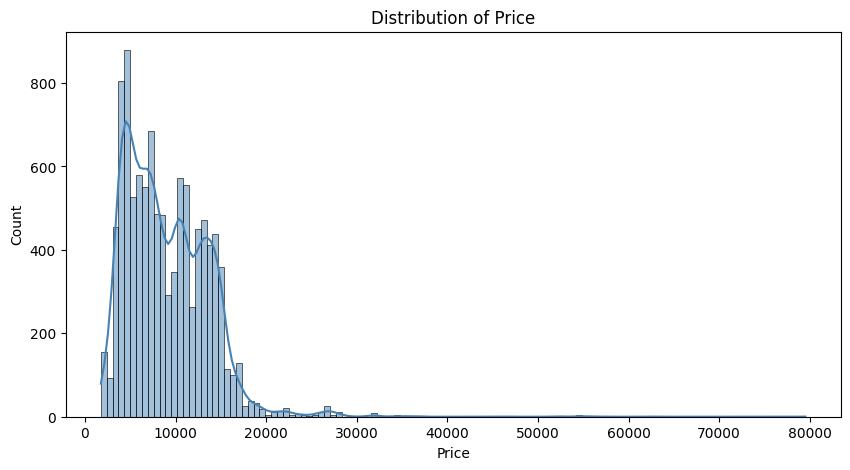

In [12]:
plt.figure(figsize=(10,5))

sns.histplot(
    data= df,
    x= "Price",
    color = "steelblue",
    kde= True
)

plt.title("Distribution of Price")

plt.show()

`Price` is right-skewed , but there's a long tail of expensive fares going up to ~₹80,000 (likely business-class/premium fares).

##### Arrival Time, Departure time, Date of Journey , Duration Conversion for Analysis

In [13]:
# Arrival Time 

df['Arrival_Hour'] = pd.to_datetime(
    df['Arrival_Time'].str[:5]
).dt.hour

df['Arrival_Minute'] = pd.to_datetime(
    df['Arrival_Time'].str[:5]
).dt.minute


# Departure Time

df['Dep_Hour'] = pd.to_datetime(
    df['Dep_Time']
).dt.hour

df['Dep_Minute'] = pd.to_datetime(
    df['Dep_Time']
).dt.minute

C:\Users\hp\AppData\Local\Temp\ipykernel_19976\2985158073.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Arrival_Hour'] = pd.to_datetime(
C:\Users\hp\AppData\Local\Temp\ipykernel_19976\2985158073.py:7: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Arrival_Minute'] = pd.to_datetime(
C:\Users\hp\AppData\Local\Temp\ipykernel_19976\2985158073.py:14: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Dep_Hour'] = pd.to_datetime(
C:\Users\hp\AppData\Local\Temp\ipykernel_19976\2985158073.py:18: UserWarning: Could not infer format, so each element will be parsed individ

In [14]:
# Convert the text column to an official DateTime Format
df['Date_of_Journey'] = pd.to_datetime(
    df['Date_of_Journey'],
    dayfirst= True)

# Extract the day and save it into a new column
df['Journey_Day'] = df['Date_of_Journey'].dt.day

# Extract the month and save it into new column
df['Journey_Month'] = df['Date_of_Journey'].dt.month
    

In [15]:
df[['Date_of_Journey', 'Journey_Day', 'Journey_Month']].head()

,Date_of_Journey,Journey_Day,Journey_Month
0,2019-03-24,24,3
1,2019-05-01,1,5
2,2019-06-09,9,6
3,2019-05-12,12,5
4,2019-03-01,1,3


In [16]:
def duration_to_minutes(x):
    hours = 0
    minutes = 0
    
    if 'h' in x:
        hours = int(x.split('h')[0])
    
    if 'm' in x:
        minutes = int(
            x.split('h')[-1]
             .replace('m', '')
             .strip()
        )
        
    return hours * 60 + minutes

In [17]:
df['Duration_min'] = df['Duration'].apply(
    duration_to_minutes
)

In [18]:
df[['Duration', 'Duration_min']].head()

,Duration,Duration_min
0,2h 50m,170
1,7h 25m,445
2,19h,1140
3,5h 25m,325
4,4h 45m,285


In [19]:
categorical_col = [
    'Airline',
    'Source',
    'Destination',
    'Total_Stops',
    'Additional_Info'
]

#### Univariate Analysis

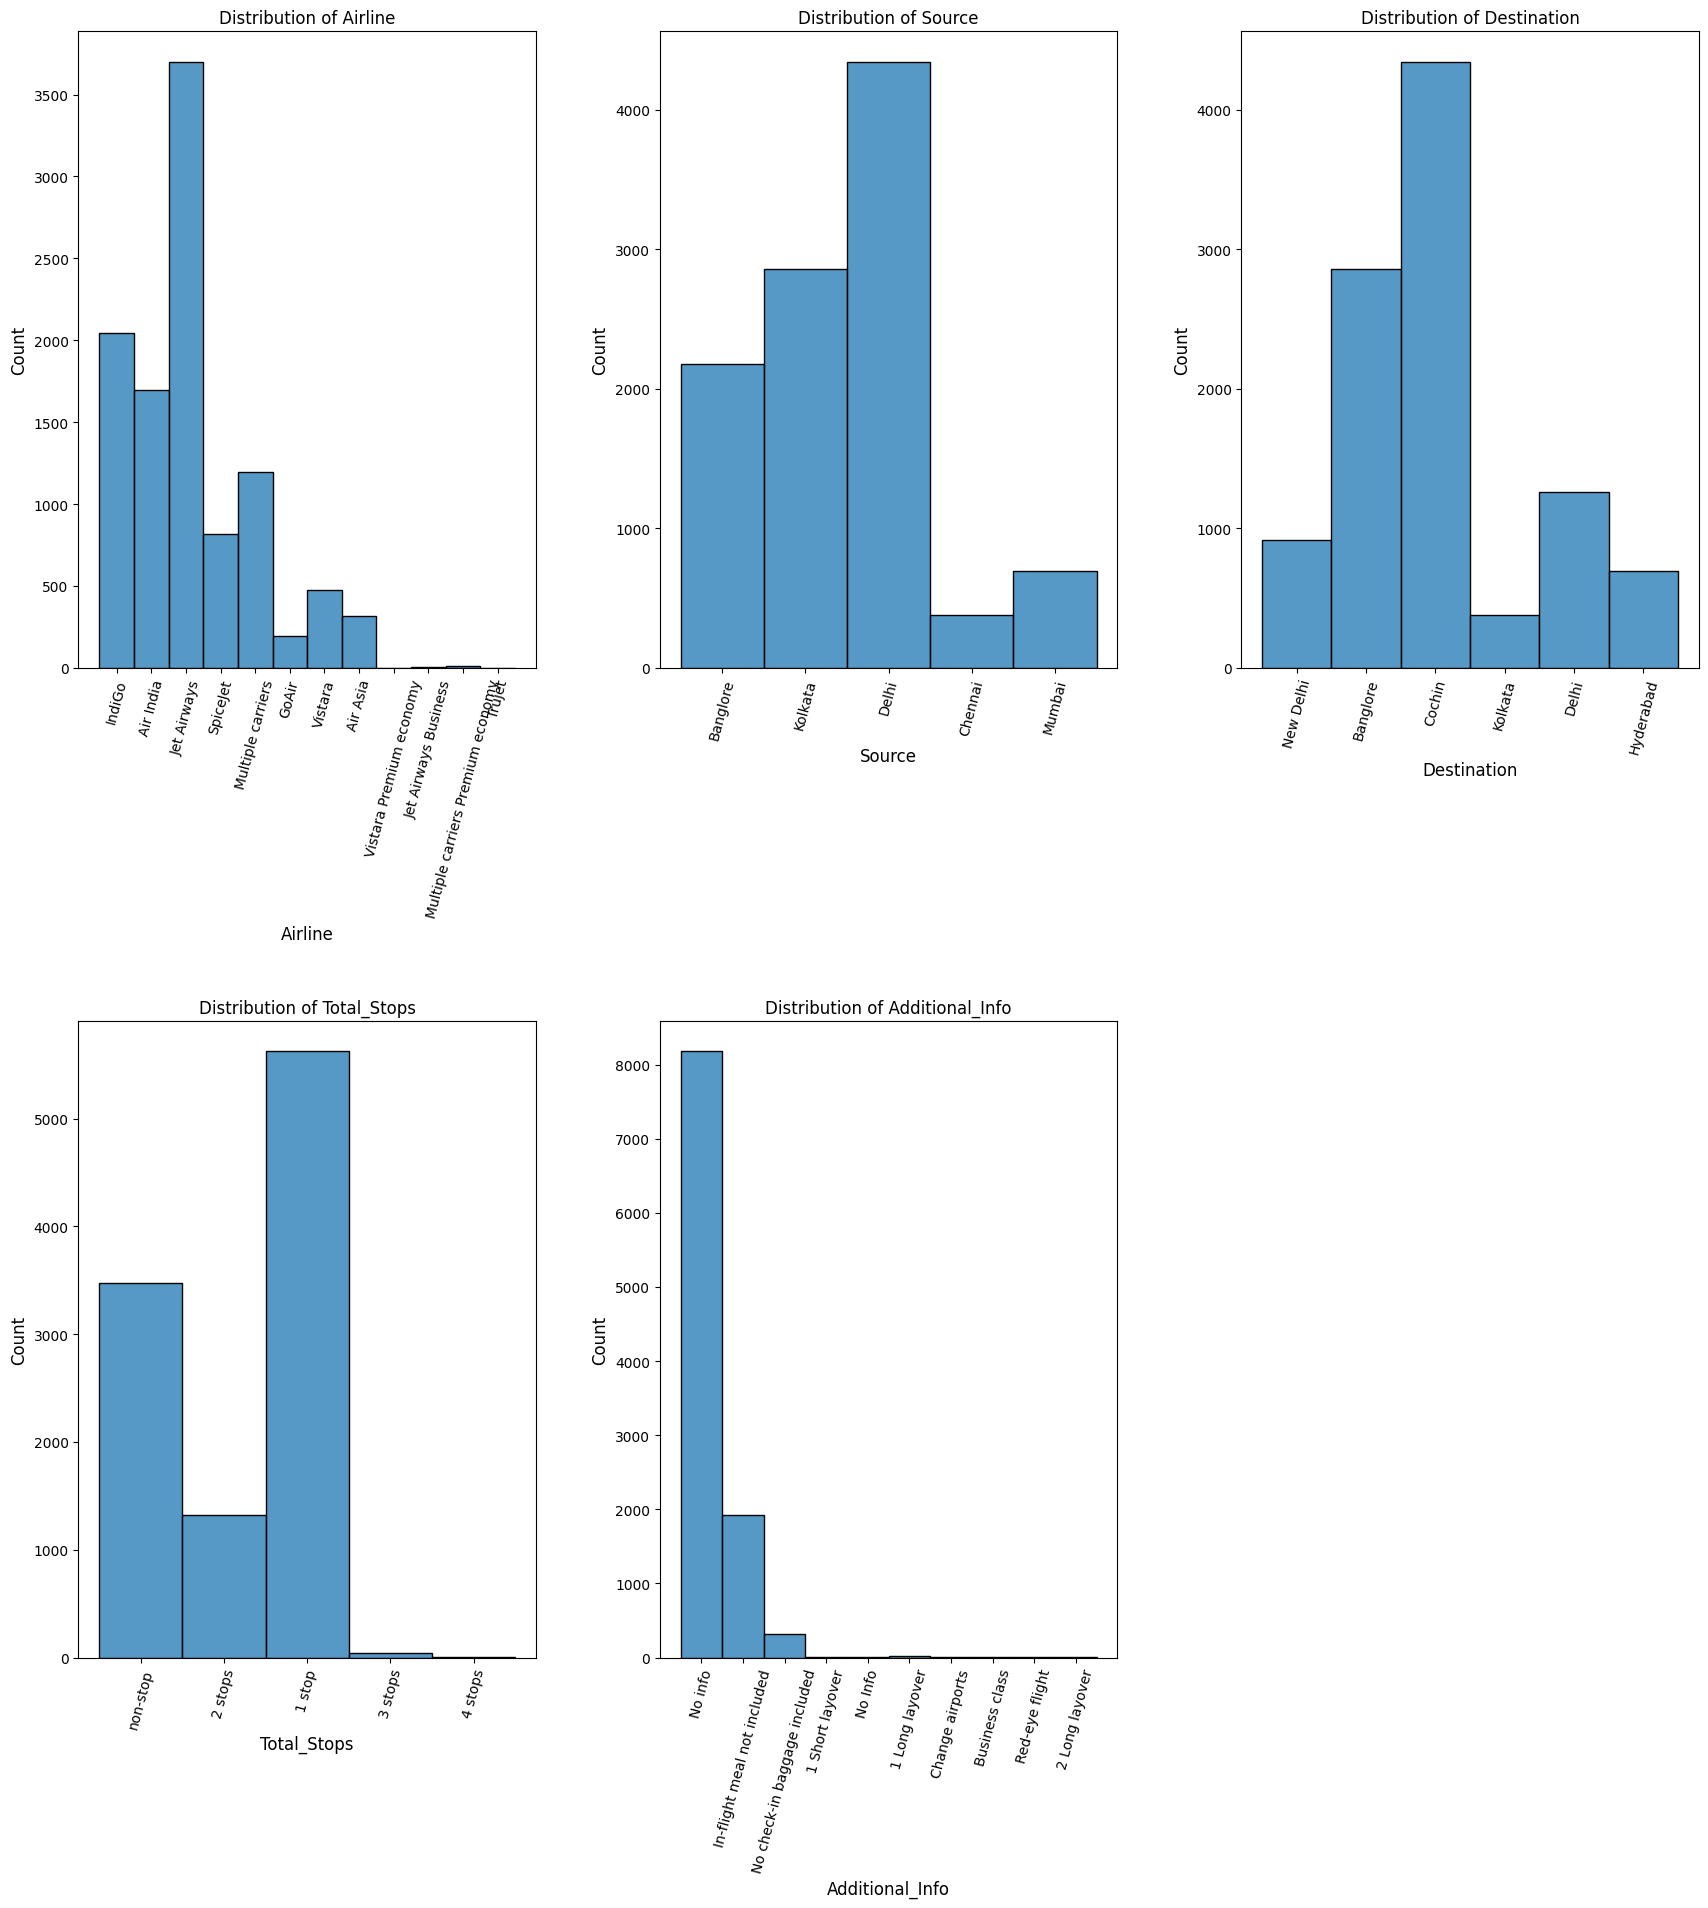

In [20]:
plt.figure(figsize=(18,20), facecolor='white')

plotnumber = 1

for column in categorical_col :

    ax = plt.subplot(2,3,plotnumber)
    sns.histplot(
        data=df,
        x=column,
        bins=30,
        kde = False
    )
    plt.title(f'Distribution of {column}')
    plt.xticks(rotation=75)
    plt.xlabel(column, fontsize=12)
    plt.ylabel('Count', fontsize=12)

    plotnumber += 1

plt.subplots_adjust(top=0.9)
plt.tight_layout(pad=4.0)
plt.show()

1. `Airline Distribution` :
   - Jet Airways is the most frequent airline in the dataset by a significant margin.
   - IndiGo and Air India follow as the next most popular choices.
   - Premium classes and regional airlines like Trujet have an extremely low footprint, making them rare categories.
2. `Source & Destination Hubs` :
   - Delhi is the dominant starting hub (Source), followed by Kolkata and Banglore.
   - Cochin is the most frequent Destination point in the entire dataset.
3. `Total Stops` :
   - Most flights in this dataset have 1 stop or are non-stop.
   - Flights with 3 or 4 stops are exceptionally rare anomalies.
4. `Additional Info` :
   - Over 75% of the entries contain No info.
   - The only other major distinct category is In-flight meal not included. Because this column is heavily dominated by a single value,                     it may have low predictive variance later.

#### Duration Distribution

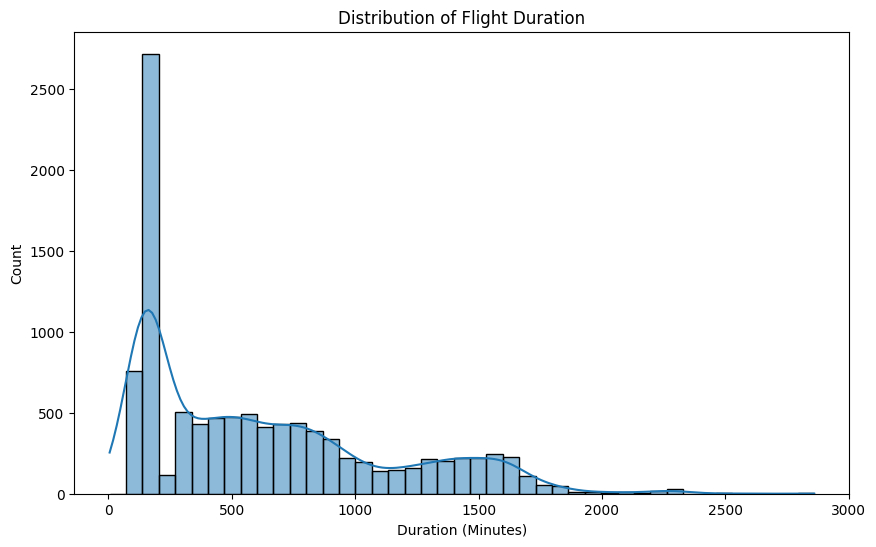

In [21]:
plt.figure(figsize=(10,6))

sns.histplot(
    df['Duration_min'],
    kde=True
)

plt.title('Distribution of Flight Duration')
plt.xlabel('Duration (Minutes)')
plt.show()

#### Box Plot — Outlier Detection

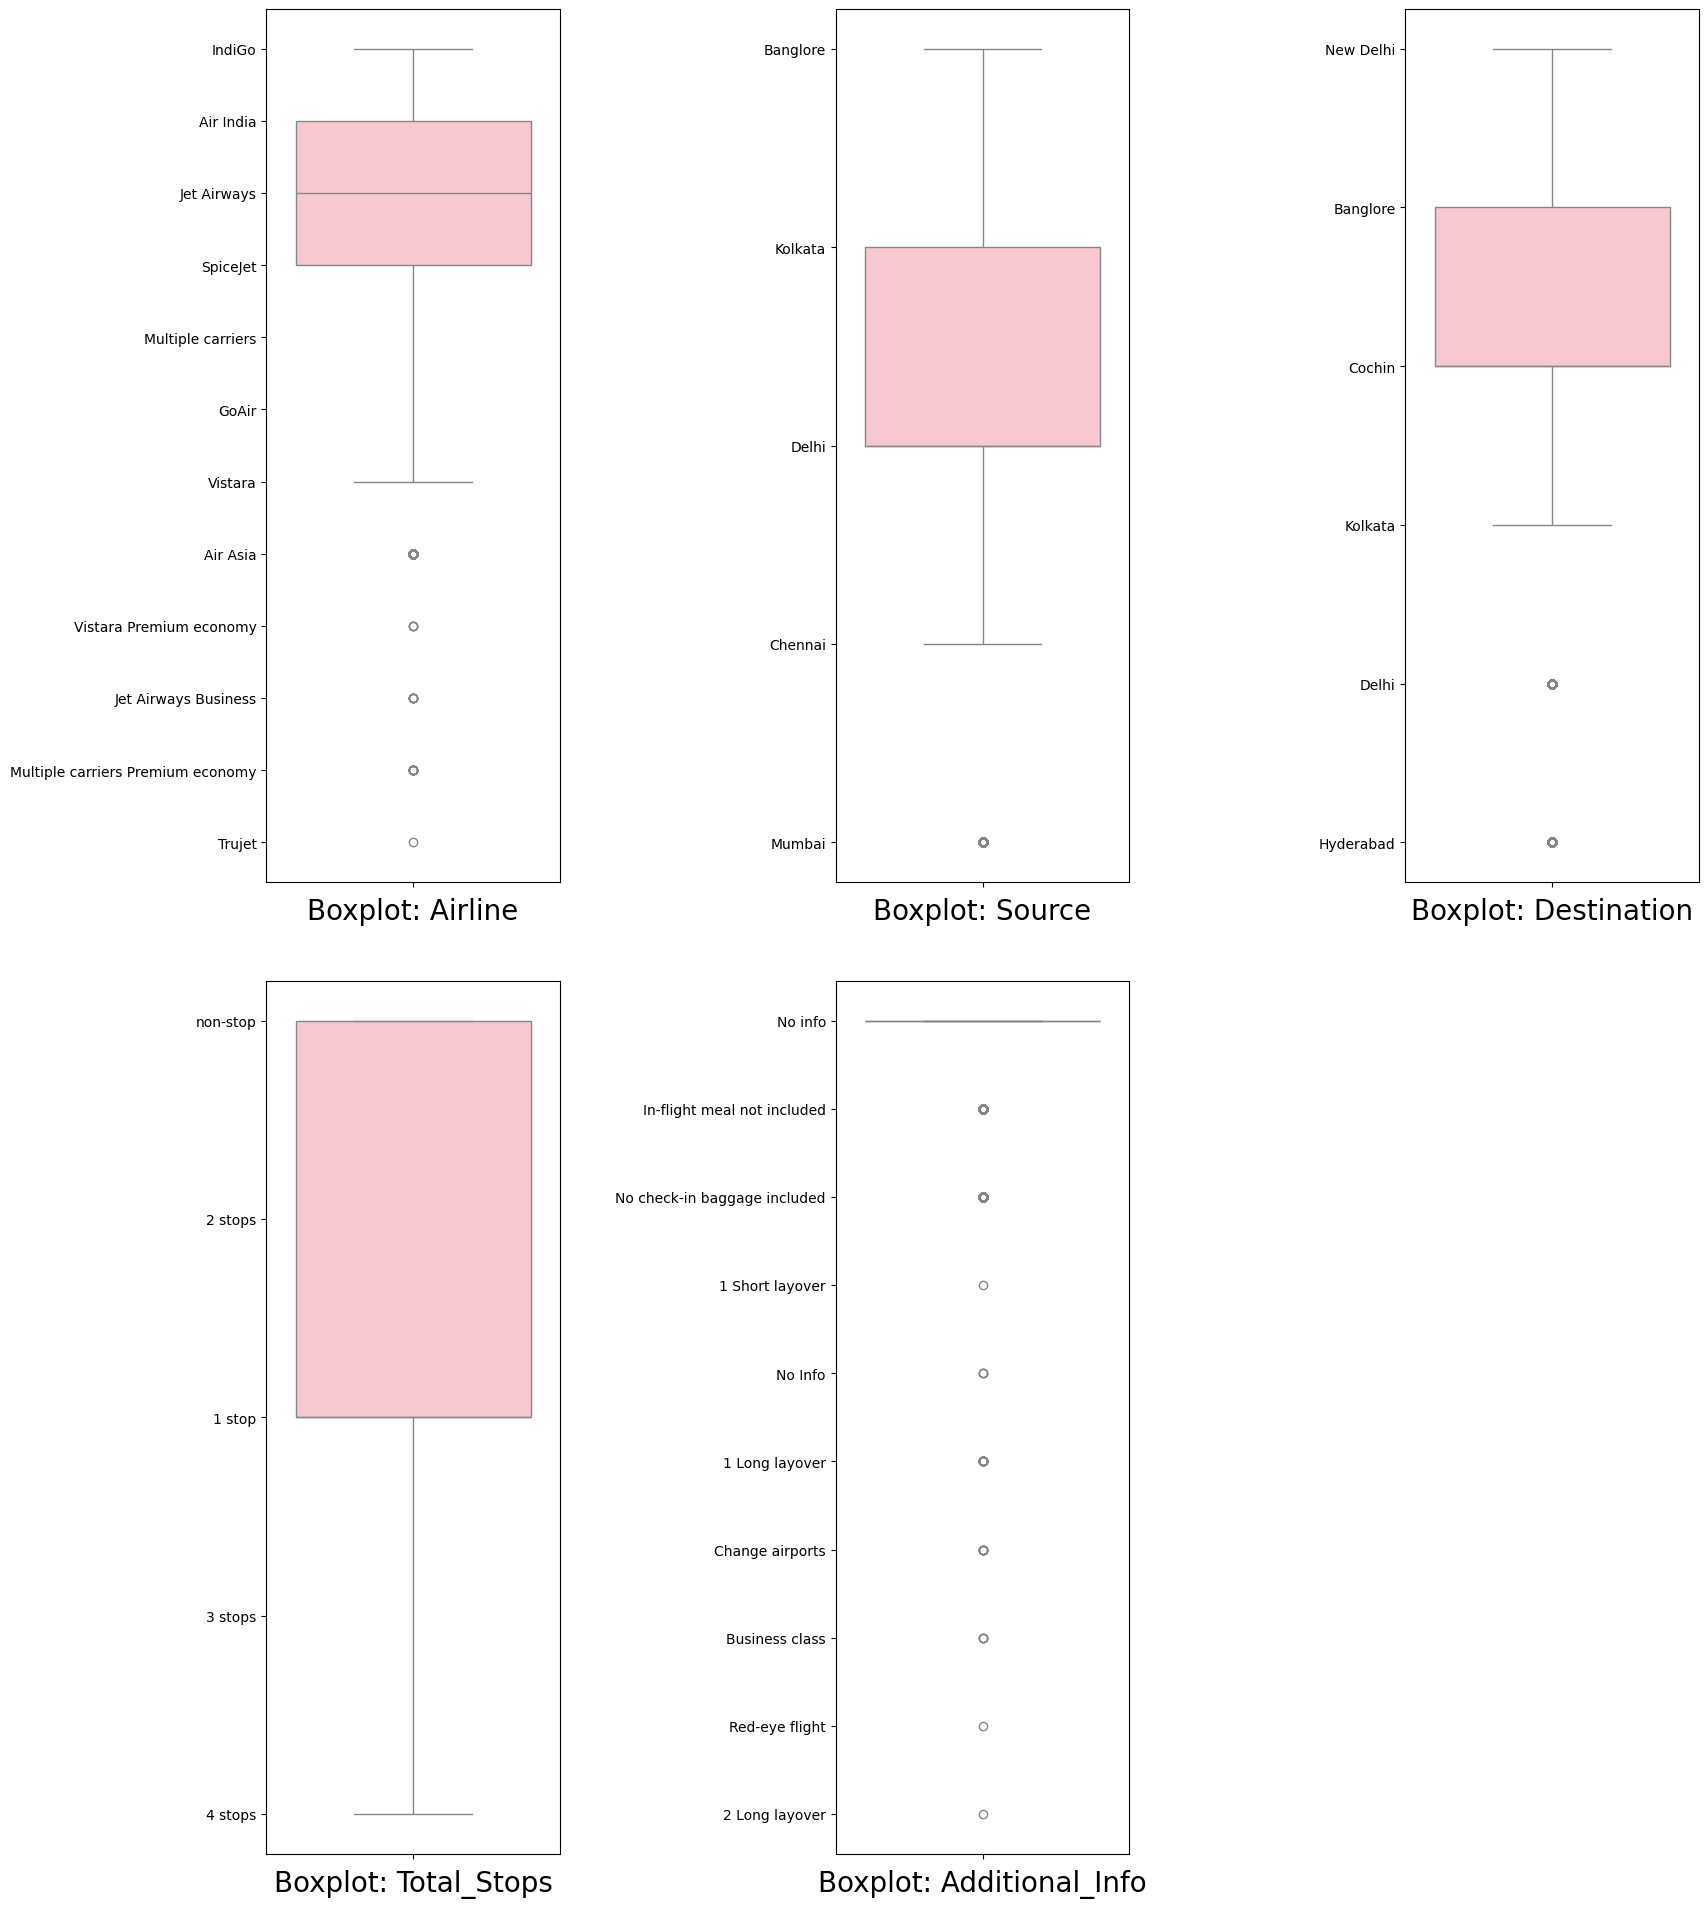

In [22]:
plt.figure(figsize=(18,20),facecolor='white')
plotnumber = 1

for column in categorical_col:
    ax =plt.subplot(2,3,plotnumber)
    sns.boxplot(df[column], color = 'Pink')

    plt.xlabel(f'Boxplot: {column}',fontsize=20)
    plt.ylabel("")

    plotnumber+=1
    
plt.tight_layout(pad=4.0)
plt.show()

1. `Airline Distribution Spread`:
   - The wide pink boxes for Jet Airways, IndiGo, and Air India show a large interquartile range (IQR), confirming that these categories contain the        overwhelming majority of the flight data records.
   - Rare categories like Trujet, Jet Airways Business, and Vistara Premium economy appear only as isolated individual points (circles) outside the         main distribution whiskers, indicating a massive data imbalance among carriers.
3. `Source & Destination Concentrated Hubs` :
   - Delhi and Kolkata have the largest, most defined box ranges under Source, showing they hold the highest density of flight departures.
   - Cochin and Banglore heavily dominate the Destination variable's data spread, proving they are the main arrival hubs in this dataset.
5. `Total Stops Structure` :
   - The large vertical pink box spans across 1 stop and non-stop, confirming that nearly the entire dataset is composed of flights with 0 or 1             layovers.Flights with 3 or 4 stops are shown as extreme, single-point outliers due to their negligible frequency.
7. `Additional Info Uniformity` :
   - The data is heavily concentrated within a single primary category (No info).All other options, including In-flight meal not included and
     No check-in baggage included, stretch out cleanly as sparse outliers, making this feature highly imbalanced.

##### Departure Time 

C:\Users\hp\AppData\Local\Temp\ipykernel_19976\1110226091.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Dep_Hour', data=df, palette='mako')


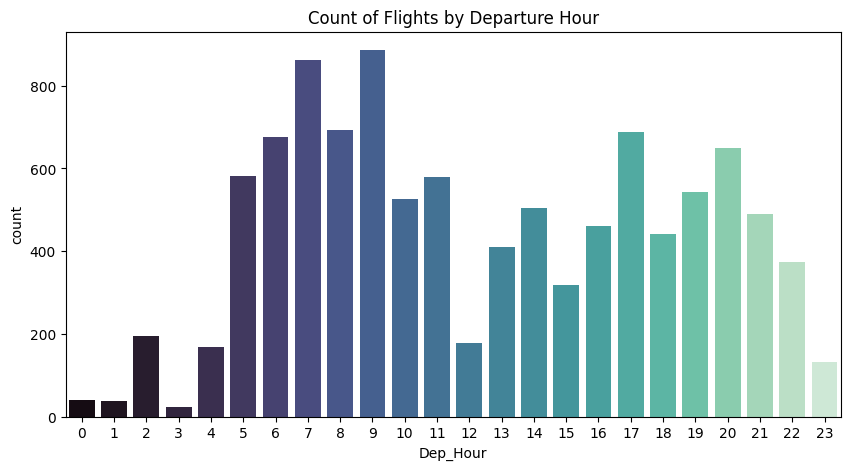

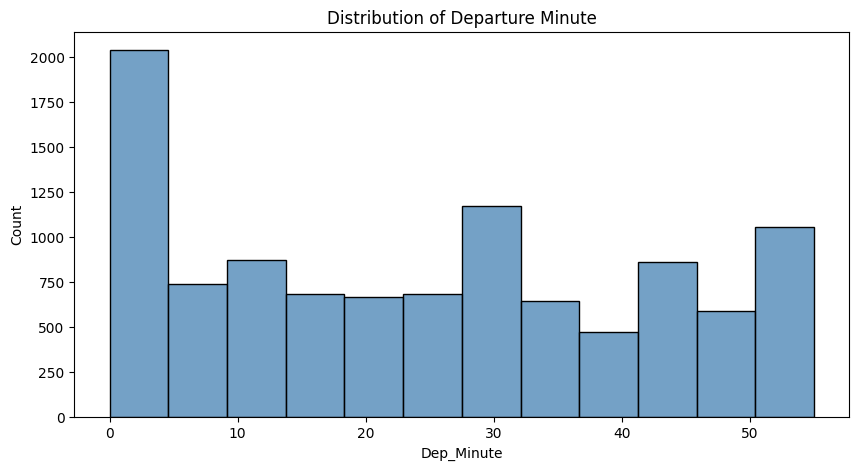

In [23]:
plt.figure(figsize=(10,5))
sns.countplot(x='Dep_Hour', data=df, palette='mako')
plt.title('Count of Flights by Departure Hour')
plt.show()

plt.figure(figsize=(10,5))
sns.histplot(df['Dep_Minute'], bins=12, color='steelblue')
plt.title('Distribution of Departure Minute')
plt.show()

Here we can see that sually mornings/evenings are busiest, with a dip late at night.

##### Date Of Journey

C:\Users\hp\AppData\Local\Temp\ipykernel_19976\1775680242.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Journey_Day', data=df, palette='crest')


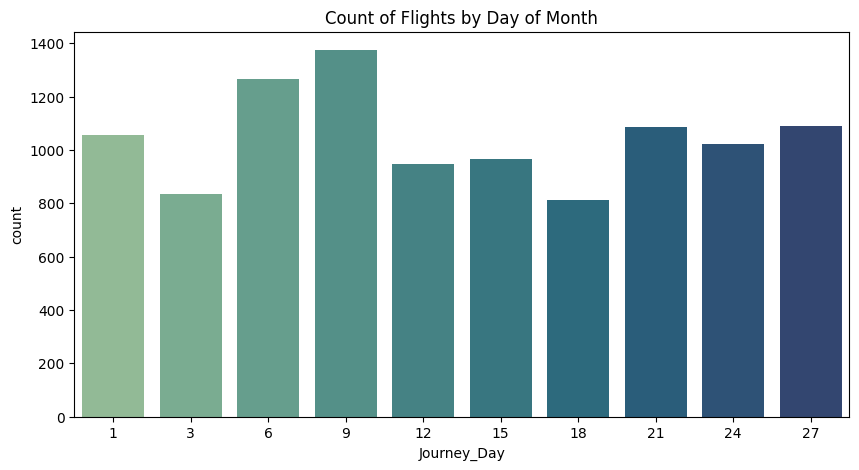

C:\Users\hp\AppData\Local\Temp\ipykernel_19976\1775680242.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Journey_Month', data=df, palette='viridis')


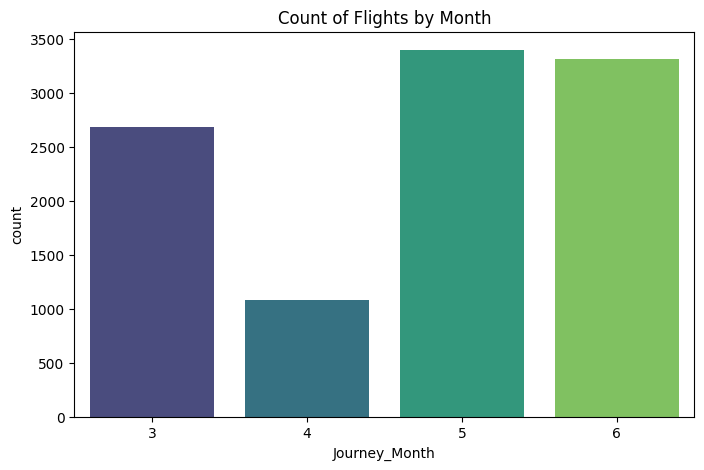

Journey_Month
5    3395
6    3311
3    2678
4    1078
Name: count, dtype: int64

In [24]:
plt.figure(figsize=(10,5))
sns.countplot(x='Journey_Day', data=df, palette='crest')
plt.title('Count of Flights by Day of Month')
plt.show()

plt.figure(figsize=(8,5))
sns.countplot(x='Journey_Month', data=df, palette='viridis')
plt.title('Count of Flights by Month')
plt.show()

df['Journey_Month'].value_counts()

1. `Dep_Hour` : Flights are heavily concentrated in early morning (5-9 AM) and evening (17-20), with very few flights around midnight-4 AM and late                    night (23). Airlines schedule most departures around typical commute/travel windows, not overnight.
2. `Journey_Day` : Flight counts vary day to day with no strong pattern, but days 6 and 9 stand out as the busiest, while days 3 and 18 are the                           quietest — likely just reflects which specific journey dates happened to be scraped for this dataset rather than a real calendar                       effect.
3. `Journey_Month` : Data is unevenly distributed — May and June have far more flights (~3,300-3,400 each) than March (~2,700) and especially April                         (~1,100). This confirms the imbalance you noted earlier — with so few April records, the model has much less to learn from that                        month, so any May/June-driven pattern may not generalize well to April

#### Bivariate Analysis

##### 1. Price vs Airline

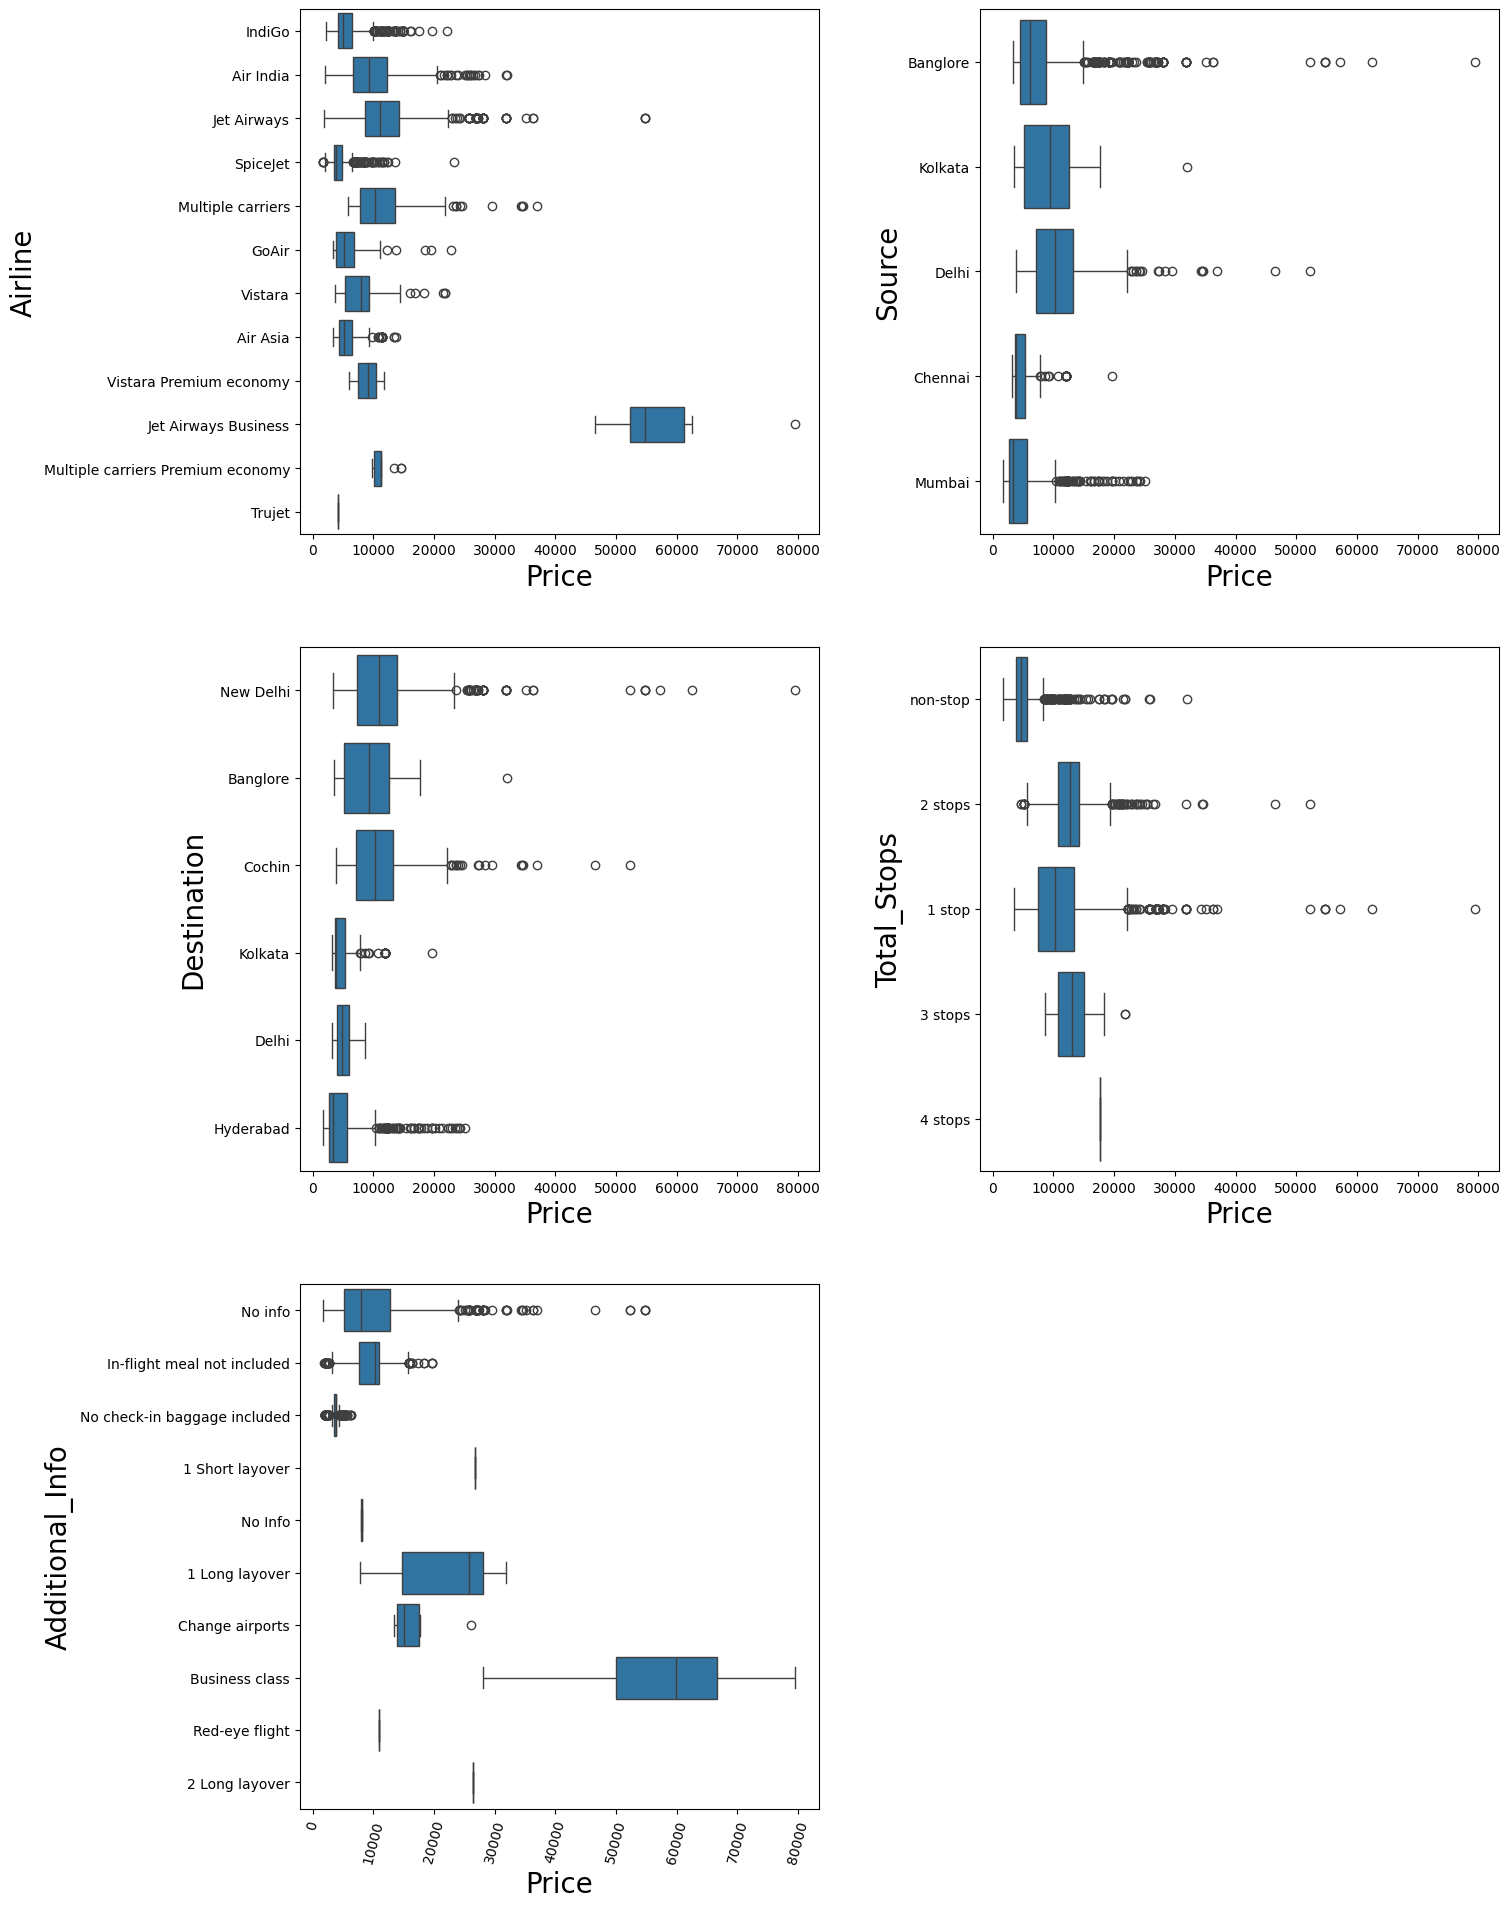

In [25]:
plt.figure(figsize=(16,20),facecolor = 'white')
plotnumber = 1

for column in categorical_col:
    ax = plt.subplot(3,2,plotnumber)
    sns.boxplot(data = df,
                x = 'Price',
                y = column
    )

    plt.xlabel('Price',fontsize =20)
    plt.ylabel(column,fontsize =20)

    plotnumber +=1

plt.xticks(rotation=75)
plt.tight_layout(pad=4.0)
plt.show()

1. `Airline` : Premium carriers like Jet Airways Business command significantly higher median prices compared to budget options like IndiGo, SpiceJet, and Air Asia, which cluster heavily under ₹15,000.   

2. `Source` : Flights originating from Kolkata and Delhi show wider price distributions and higher median fares, whereas Chennai and Mumbai consistently display lower median prices with minimal spread.

3. `Destination` : New Delhi, Cochin, and Bangalore destinations exhibit broader price ranges with high-value extreme outliers above ₹30,000, while Kolkata, Delhi, and Hyderabad stay tightly compressed below ₹30,000.

4. `Total_Stops` : Clear positive relationship between stops and fare—non-stop flights remain cheap and concentrated, whereas 1 stop and 2 stops push the median price higher along with increased variability.   

5. `Additional_Info` : Business class dominates top-tier pricing. Categories like 1 Long layover and Change airports also show elevated median fares relative to standard No info or In-flight meal not included bookings.

##### 2. Date_of_Journey(Journey_month & Journey_Day) VS Price 

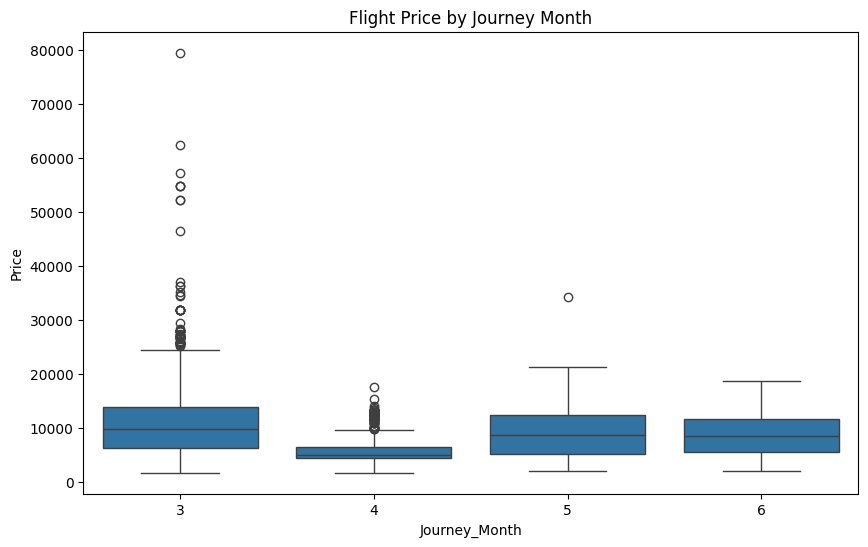

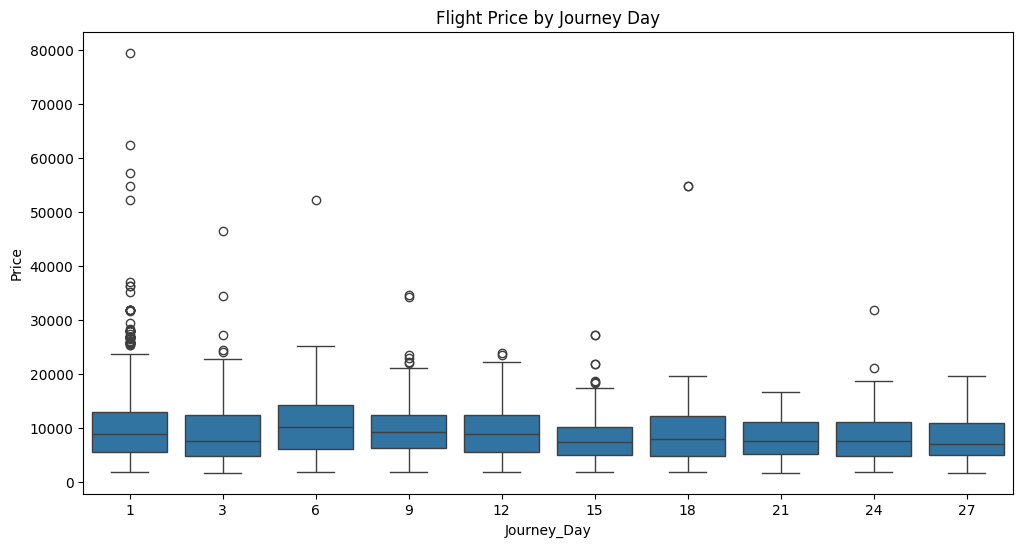

In [26]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=df,
    x='Journey_Month',
    y='Price'
)

plt.title('Flight Price by Journey Month')
plt.show()


plt.figure(figsize=(12,6))

sns.boxplot(
    data=df,
    x='Journey_Day',
    y='Price'
)

plt.title('Flight Price by Journey Day')
plt.show()

##### 3. Depature_Time VS Price 

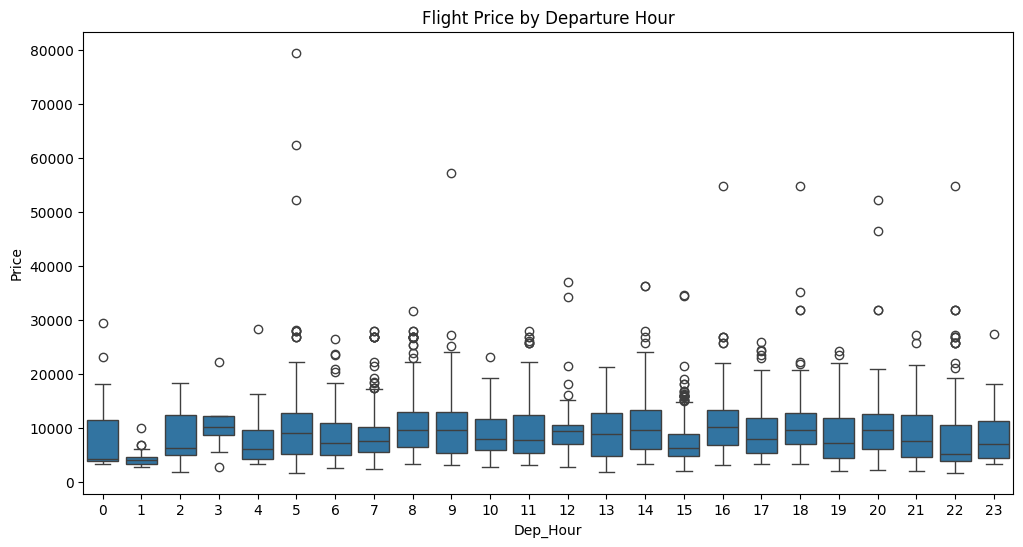

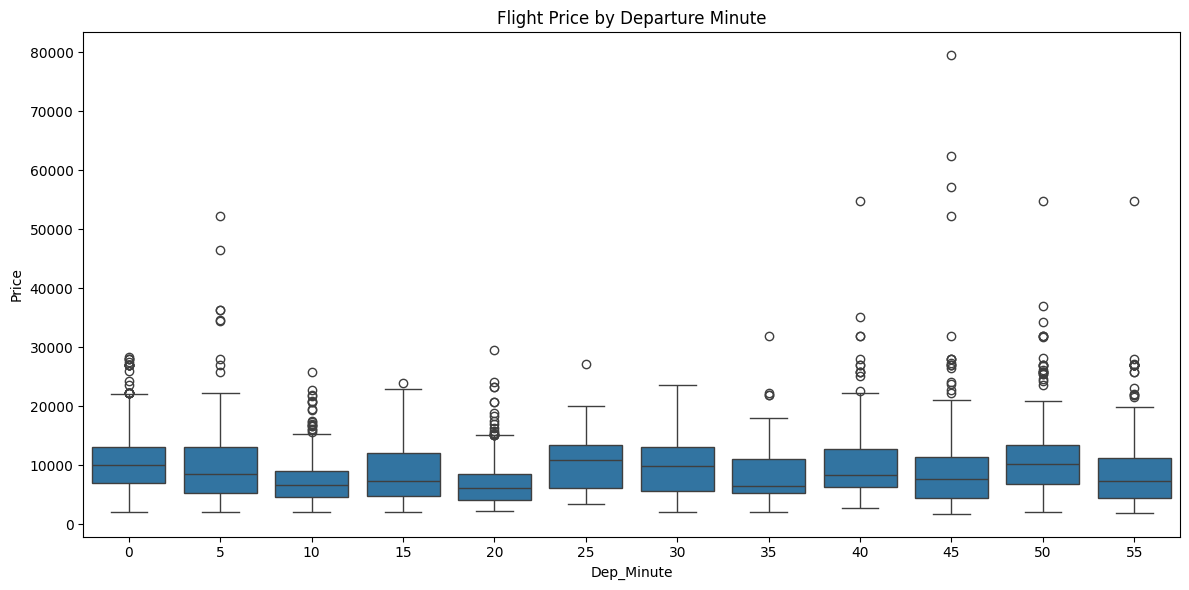

In [27]:
plt.figure(figsize=(12,6))

sns.boxplot(
    data=df,
    x='Dep_Hour',
    y='Price'
)

plt.title('Flight Price by Departure Hour')


plt.figure(figsize=(12,6))

sns.boxplot(
    data=df,
    x='Dep_Minute',
    y='Price'
)

plt.title('Flight Price by Departure Minute')


plt.tight_layout()
plt.show()

##### 4. Arrival_Time VS Price 

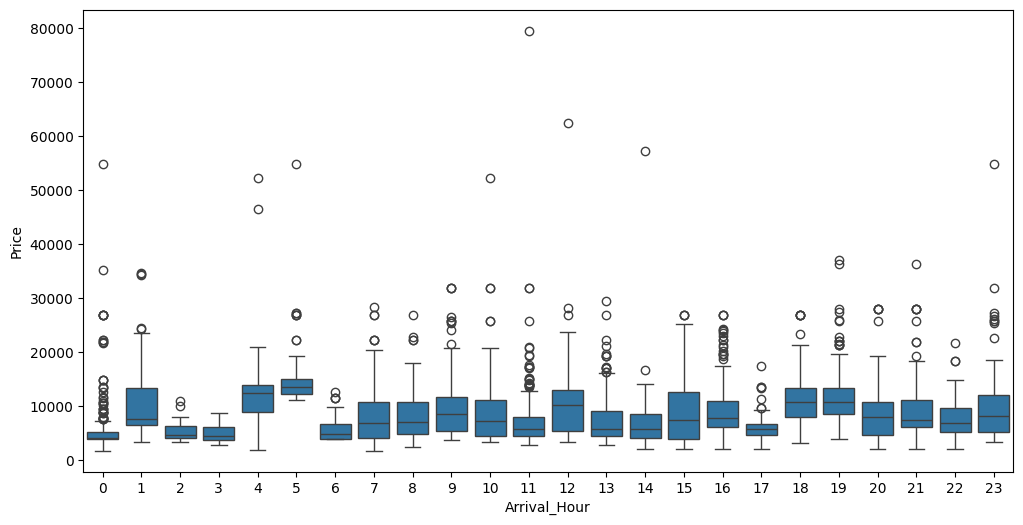

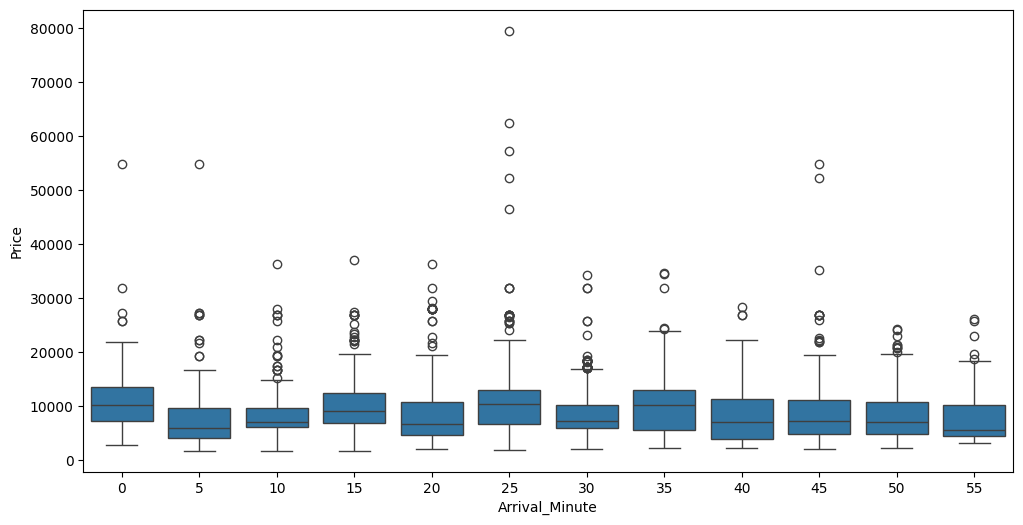

In [28]:
plt.figure(figsize=(12,6))

sns.boxplot(
    data=df,
    x='Arrival_Hour',
    y='Price'
)

plt.figure(figsize=(12,6))

sns.boxplot(
    data=df,
    x='Arrival_Minute',
    y='Price'
)

plt.show()

1. `Dep_Hour` : Price bounces around with no clear trend by hour — a weak, noisy                        predictor on its own.
2. `Dep_Minute` : No real pattern at all — makes sense, since departure minute has no                     logical reason to affect price. Likely a droppable feature.
3. `Journey_Day` : Mild downward trend — prices tend to be higher early in the month                       and lower toward month-end, though still noisy.
4. `Journey_Month` : Clear differences across months (March highest, April lowest), but                      only 4 months are in the data, so this can't be trusted as a                            real seasonal pattern.
5. `Arrival_Time` : Arrival time shows variation in flight fares. Prices are fairly                         similar across hours (medians mostly) --

    -- Hour 0 & 17: cheapest, most consistent.
   
    -- Hours 1, 4, 5, 18, 19: highest medians & most spread — likely                                                  peak/premium times.
   
    -- Hour 11: has an extreme outlier (~80k) — worth checking if it's real or                         a data error.
   
    -- Midday/evening hours (9–13, 15–19) show more outliers and variability                   than early morning hours (2, 3, 6, 14, 17, 20, 22).
   
    -- Right-skew (upper outliers) is present in nearly every hour, typical for                price data.

##### 5. Duration VS Price

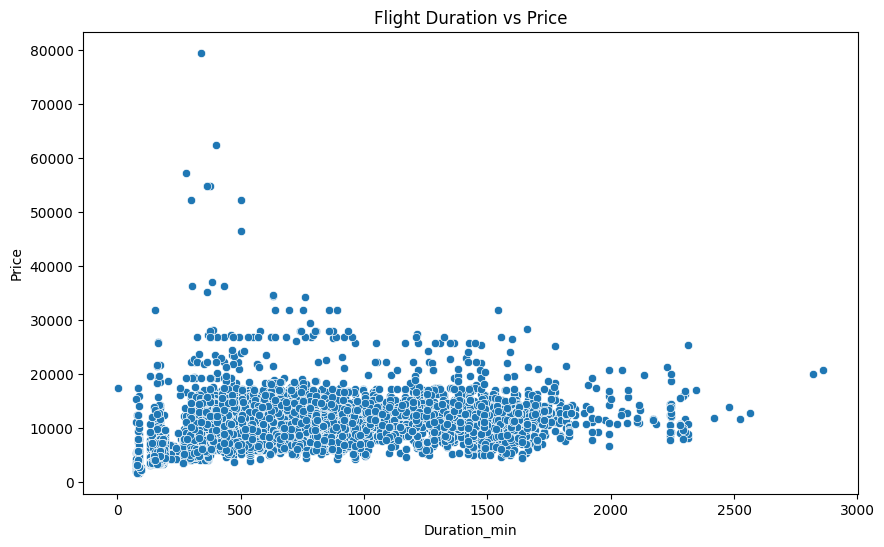

In [29]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x='Duration_min',
    y='Price'
)

plt.title('Flight Duration vs Price')
plt.show()

-- No strong linear trend — price stays roughly flat (5k–25k) across almost all durations.

-- Outlier hotspot: ~300–500 min — this range holds the extreme high-price points (₹45k–₹80k), including the single highest point at ~350 min, ₹80,000.

-- Short flights (<200 min) still range widely, from near ₹0 to ~₹35,000.

-- Long flights (>2000 min) thin out and stay mostly under ₹20,000 — no premium for longer duration

### Feature Engineering

#### Convert Total Stops

In [30]:
from sklearn.preprocessing import OrdinalEncoder

stops_order =[['non-stop', '1 stop', '2 stops', '3 stops', '4 stops']]

oe = OrdinalEncoder(categories = stops_order, dtype =int)

df['Total_Stops_num'] = oe.fit_transform(df[['Total_Stops']])

In [31]:
print(df[['Total_Stops', 'Total_Stops_num']].head())

  Total_Stops  Total_Stops_num
0    non-stop                0
1     2 stops                2
2     2 stops                2
3      1 stop                1
4      1 stop                1


- Total_Stops" has a natural order (non-stop < 1 stop < 2 stops < 3 stops < 4 stops), so OrdinalEncoder with explicit categories=stops_order is         better than one-hot encoding, which would lose that ranking information.
- dtype=int keeps the output as integers rather than floats, which is a nice touch for readability, though it won't affect model performance either     way.
- The output confirms it worked correctly: non-stop → 0, 1 stop → 1, 2 stops → 2, matching your defined order.

#### Correlation Heatmap (for numeric features)

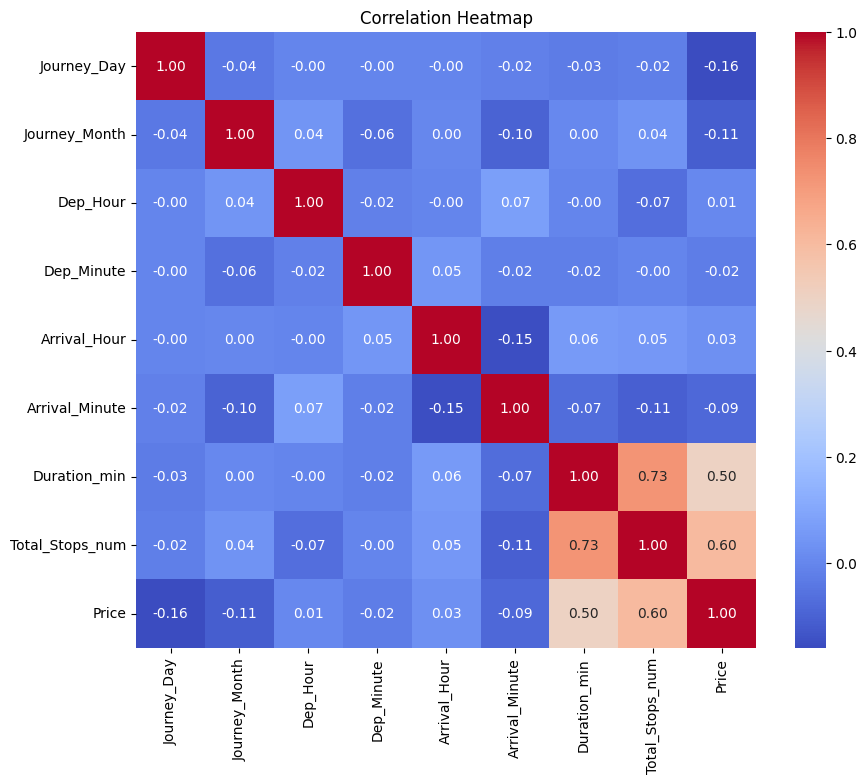

In [32]:
corr_cols = [
    'Journey_Day',
    'Journey_Month',
    
    'Dep_Hour',
    'Dep_Minute',
    
    'Arrival_Hour',
    'Arrival_Minute',
    
    'Duration_min',
    
    'Total_Stops_num',

    'Price'

]
corr = df[corr_cols].corr()
plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Correlation Heatmap")

plt.show()


1. `Duration_min` and `Total_Stops_num` correlate most strongly nearly about 0.75 —         matching what we already saw in the bivariate boxplot and scatter plot above.
2. `Duration_min` shows a moderate positive relationship with price(0.51).
3. Whereas `Departure Time` and `Arrival Time` have relatively weak linear                 correlations.
 

### Defining Feature and Target Variable

In [36]:
features = [
    'Airline',
    'Source',
    'Destination',
    'Route',
    'Additional_Info',
    
    'Journey_Day',
    'Journey_Month',
    
    'Dep_Hour',
    'Dep_Minute',
    
    'Arrival_Hour',
    'Arrival_Minute',
    
    'Duration_min',
    
    'Total_Stops_num'
]

In [37]:
categorical_features = [
    'Airline',
    'Source',
    'Destination',
    'Route',
    'Additional_Info'
]

numerical_features = [
    'Journey_Day',
    'Journey_Month',
    'Dep_Hour',
    'Dep_Minute',
    'Arrival_Hour',
    'Arrival_Minute',
    'Duration_min',
    'Total_Stops_num'
]

- Structure is correct: categorical columns → OneHotEncoder, numerical columns → passthrough, combined via ColumnTransformer. 
- handle_unknown='ignore' — prevents errors if the test/future data has a category not seen in training .
- passthrough for numerical features means they won't be scaled .

In [38]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            'categorical',
            OneHotEncoder(handle_unknown='ignore'),
            categorical_features
        ),
        (
            'numerical',
            'passthrough',
            numerical_features
        )
    ]
)

##### Define X and Y

In [39]:
X = df[features]

Y = df['Price']

In [40]:
df['Price'].head()

0     3897
1     7662
2    13882
3     6218
4    13302
Name: Price, dtype: int64

#### Train-Test Split

In [41]:
X_train, X_test, Y_train, Y_test = train_test_split(
    X,
    Y,
    test_size=0.20,
    random_state=42

)

### Importing Libraries for Models

In [42]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

###  Creating Multiple Pipelines for Multiple Models

In [43]:
lr_pipeline = Pipeline(steps=[

    ("preprocessor", preprocessor),

    ("classifier", LinearRegression())

])

In [44]:
dt_pipeline = Pipeline(steps=[

    ("preprocessor", preprocessor),
    
    ("classifier", DecisionTreeRegressor())

])

In [45]:
rf_pipeline = Pipeline(steps=[

    ("preprocessor", preprocessor),

    ("classifier", RandomForestRegressor())

])

In [46]:
xgb_pipeline = Pipeline(steps=[

    ("preprocessor", preprocessor),

    ("classifier", XGBRegressor())
])

In [47]:
# Storing all the Model names and Model_pipeline for better structured training and evaluation of the Models
models = {

    "Linear Regression": lr_pipeline,
    
    "Decission Tree": dt_pipeline,
    
    "Random Forest": rf_pipeline,

    "XGBoost": xgb_pipeline

}

## Training and Evaluating the Models

In [48]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


In [49]:
results = []

for name, model in models.items():

    #train
    model.fit(X_train, Y_train)

    #predict
    Y_pred = model.predict(X_test)

    mae = mean_absolute_error(Y_test, Y_pred)
    rmse = mean_squared_error(Y_test, Y_pred) ** 0.5
    r2 = r2_score(Y_test, Y_pred)

    results.append({
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R2 Score": r2
    })

results_df = pd.DataFrame(results)
print(results_df)

               Model          MAE         RMSE  R2 Score
0  Linear Regression  1542.707582  2434.320110  0.715787
1     Decission Tree   745.944498  1851.453250  0.835596
2      Random Forest   621.980981  1428.047538  0.902192
3            XGBoost   804.469543  1479.508533  0.895016


- Random Forest is the best: lowest RMSE (1431), highest R² (0.902) — explains ~90% of price variance.
- XGBoost is close second: R² 0.895, RMSE 1479 — very competitive with Random Forest.
- Decision Tree is decent but weaker: R² 0.834, higher error than the ensembles.
- Linear Regression is clearly the weakest: R² only 0.716, much higher MAE/RMSE .

C:\Users\hp\AppData\Local\Temp\ipykernel_19976\804438091.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot( data=results_df, x='Model', y='RMSE',palette='viridis')


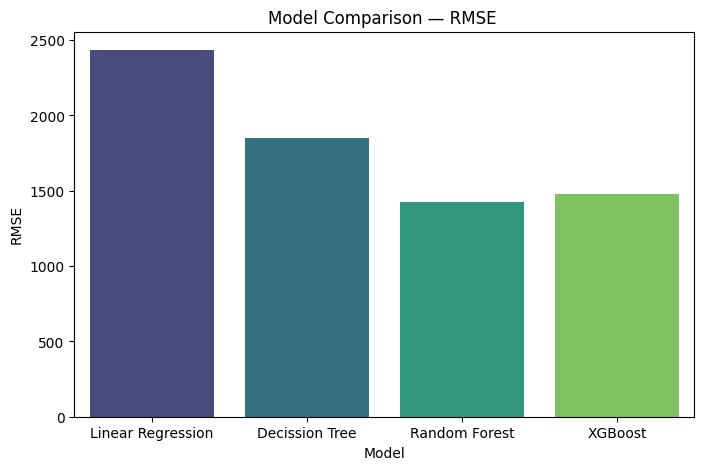

In [50]:
plt.figure(figsize=(8,5))
sns.barplot( data=results_df, x='Model', y='RMSE',palette='viridis')
plt.title('Model Comparison — RMSE ')
plt.show()

Random Forest and XGBoost (tree ensembles) clearly beat Linear Regression, confirming what the correlation heatmap suggested — price depends on non-linear combinations of airline × route × duration × stops, not a simple linear formula. The best of the two is recommended for production; Linear Regression is kept only as an interpretable baseline.

## Comparing Cross Validation Score for the Models

In [51]:
from sklearn.model_selection import cross_val_score

cv_results = []
for name, model in models.items():
    scores = cross_val_score(
        model,
        X_train,
        Y_train,
        cv=5, 
        scoring='r2',
        n_jobs=-1)
    
    cv_results.append({
        "Model": name,
        "Mean R2 (CV)": scores.mean(),
        "Std R2 (CV)": scores.std()
    })

cv_df = pd.DataFrame(cv_results)
print(cv_df)

               Model  Mean R2 (CV)  Std R2 (CV)
0  Linear Regression      0.740778     0.031233
1     Decission Tree      0.841424     0.028397
2      Random Forest      0.898885     0.008986
3            XGBoost      0.901107     0.011813


- XGBoost is now marginally the best (R² 0.901) vs Random Forest (R² 0.900).
- Random Forest has the lowest std (0.010) — slightly more stable/consistent across folds than XGBoost (0.0118).
- Decision Tree (R² 0.848) confirms it's meaningfully behind the ensembles.
- Linear Regression (R² 0.741) confirms it's the weakest.

## Hyperparameter Tuning

In [56]:
from sklearn.model_selection import RandomizedSearchCV

xgb_params = {

    'classifier__n_estimators': [100, 200],

    'classifier__max_depth': [3, 5, 7],

    'classifier__learning_rate': [0.01, 0.05, 0.1],

    'classifier__subsample': [0.8, 1.0],

    'classifier__colsample_bytree': [0.8, 1.0]

}

xgb_random_search = RandomizedSearchCV(

    estimator=xgb_pipeline,

    param_distributions=xgb_params,

    n_iter=10,

    cv=5,

    scoring='r2',

    random_state=42,

    n_jobs=-1

)

# Train XGBoost Tuning
xgb_random_search.fit(X_train, Y_train)

# Best Parameters
print("Best XGBoost Parameters:")
print(xgb_random_search.best_params_)

# Best Score
print("\nBest XGBoost CV Score:")
print(xgb_random_search.best_score_)

# Best Model
best_xgb_model = xgb_random_search.best_estimator_

Best XGBoost Parameters:
{'classifier__subsample': 0.8, 'classifier__n_estimators': 200, 'classifier__max_depth': 7, 'classifier__learning_rate': 0.1, 'classifier__colsample_bytree': 0.8}

Best XGBoost CV Score:
0.9099491238594055


In [54]:
rf_params = {

    'classifier__n_estimators': [100, 200],

    'classifier__max_depth': [10, 20, 30, None],

    'classifier__min_samples_split': [2, 5, 10],

    'classifier__min_samples_leaf': [1, 2, 4],

    'classifier__max_features': ['sqrt', 'log2']

}

rf_random_search = RandomizedSearchCV(

    estimator=rf_pipeline,

    param_distributions=rf_params,

    n_iter=10,

    cv=5,

    scoring='r2',

    random_state=42,

    n_jobs=-1

)

# Train Random Forest Tuning
rf_random_search.fit(X_train, Y_train)

# Best Parameters
print("Best Random Forest Parameters:")
print(rf_random_search.best_params_)

# Best Score
print("\nBest Random Forest CV Score:")
print(rf_random_search.best_score_)

# Best Model
best_rf_model = rf_random_search.best_estimator_

Best Random Forest Parameters:
{'classifier__n_estimators': 100, 'classifier__min_samples_split': 5, 'classifier__min_samples_leaf': 1, 'classifier__max_features': 'log2', 'classifier__max_depth': 20}

Best Random Forest CV Score:
0.8363368859405526


**XGBoost** : CV R² = 0.910 — improved from the untuned CV score of 0.901. A real gain from tuning.
Best params: n_estimators=200, max_depth=7, learning_rate=0.1, subsample=0.8.

**Random Forest** : CV R² = 0.836 — this is actually worse than your untuned Random Forest CV score from earlier (0.899). That's unusual — tuning is supposed to find parameters at least as good as the defaults,

`RandomizedSearchCV with n_iter=10 only tries 10 random combinations out of many possible ones so I will increase n_iter so it samples more combinations (better chance of finding a good one) `

In [61]:
xgb_random_search = RandomizedSearchCV(
    estimator=xgb_pipeline,
    param_distributions=xgb_params,
    n_iter=50,     # was 10
    cv=5, scoring='r2', random_state=42, n_jobs=-1
)
xgb_random_search.fit(X_train, Y_train)
print(xgb_random_search.best_params_)
print(xgb_random_search.best_score_)

{'classifier__subsample': 0.8, 'classifier__n_estimators': 200, 'classifier__max_depth': 7, 'classifier__learning_rate': 0.1, 'classifier__colsample_bytree': 0.8}
0.9099491238594055


In [60]:
rf_random_search = RandomizedSearchCV(
    estimator=rf_pipeline,
    param_distributions=rf_params,
    n_iter=50,     # was 10
    cv=5, scoring='r2', random_state=42, n_jobs=-1
)
rf_random_search.fit(X_train, Y_train)
print(rf_random_search.best_params_)
print(rf_random_search.best_score_)

{'classifier__n_estimators': 200, 'classifier__min_samples_split': 2, 'classifier__min_samples_leaf': 1, 'classifier__max_features': 'sqrt', 'classifier__max_depth': 30}
0.8799519988109671


- XGBoost improved with tuning (0.901 → 0.910) and is now the clear leader — confirms the earlier gain from n_iter=10 wasn't a fluke; more search iterations held the same conclusion.
 
- Random Forest still did not improve with tuning, even at n_iter=50 (0.899 → 0.880). With 50 sampled combinations, the honest conclusion is that Random Forest's default hyperparameters were already close to its ceiling for this dataset, and the custom search space tried here didn't contain a genuinely better combination than the defaults.

### Actual vs Predicted Plot

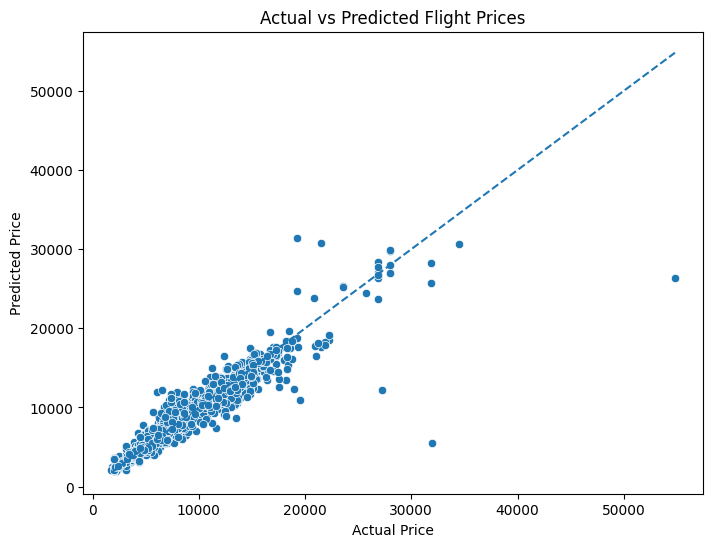

In [67]:
# Predict on the test data using the tuned XGBoost model
Y_pred_xgb = best_xgb_model.predict(X_test)

plt.figure(figsize=(8,6))

sns.scatterplot(x=Y_test, y=Y_pred_xgb)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Flight Prices")

plt.plot(
    [Y_test.min(), Y_test.max()],
    [Y_test.min(), Y_test.max()],
    linestyle='--'
)

plt.show()

- Most points are close to the diagonal line, showing good prediction accuracy.
- The model captures the overall relationship between actual and predicted prices well.
- Some points are far from the line, indicating larger prediction errors/outliers.
- Higher-priced flights show more noticeable deviations from actual prices.
  
`Overall, the tuned XGBoost model shows strong predictive performance.`

#### Feature Importance

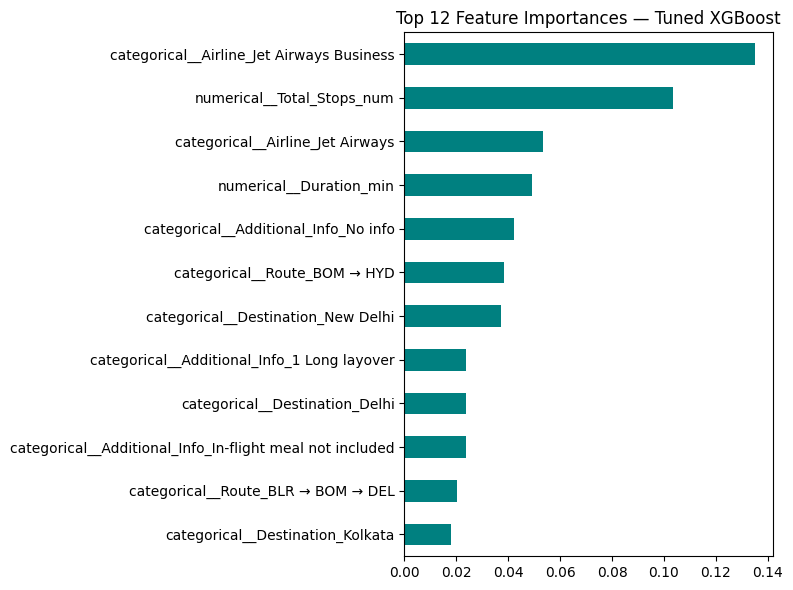

categorical__Airline_Jet Airways Business                   0.135062
numerical__Total_Stops_num                                  0.103280
categorical__Airline_Jet Airways                            0.053278
numerical__Duration_min                                     0.049275
categorical__Additional_Info_No info                        0.042241
categorical__Route_BOM → HYD                                0.038348
categorical__Destination_New Delhi                          0.037038
categorical__Additional_Info_1 Long layover                 0.023821
categorical__Destination_Delhi                              0.023754
categorical__Additional_Info_In-flight meal not included    0.023753
categorical__Route_BLR → BOM → DEL                          0.020374
categorical__Destination_Kolkata                            0.018099
dtype: float32

In [62]:
importances = pd.Series(
    best_xgb_model.named_steps['classifier'].feature_importances_,
    index=best_xgb_model.named_steps['preprocessor'].get_feature_names_out()
).sort_values(ascending=False).head(12)

plt.figure(figsize=(8,6))
importances.sort_values().plot(kind='barh', color='teal')
plt.title('Top 12 Feature Importances — Tuned XGBoost')
plt.tight_layout()
plt.show()
importances

- `Airline_Jet Airways Business` is by far the single most important feature (0.135) — confirms the EDA finding that this specific airline/class -       combination is priced dramatically differently from everything else.
- `Total_Stops_num` is the second most important (0.103) — confirms stops is a genuine, strong price driver, consistent with the bivariate boxplot       from earlier.
- `Airline_Jet Airways` and `Duration_min` are the next tier — both expected, matching EDA.

## Challenges Faced

|  | Challenge | How handled |
|---|---|---|
|  Missing values were present in the dataset | Missing values were identified and handled during data cleaning to ensure that incomplete records did not affect model training.|
|  Date of journey was stored as a date value | The date was converted into meaningful features such as journey day and journey month for model training. |
|  Departure and arrival times were stored as text |	Hour and minute components were extracted from the time columns and converted into numerical features. |
|  Flight duration was stored in hours and minutes format | Duration was converted into total minutes so that it could be directly used as a numerical feature. |
| Total stops contained categorical values such as non-stop and stop counts | The values were converted into numerical representations indicating the number of stops. |
| Several categorical features were present, such as Airline, Source, Destination, Route and Additional_Info | One-Hot Encoding was applied using OneHotEncoder to convert categorical variables into numerical features. |
| Route contained a relatively large number of unique categories | Route was retained because it provides detailed information about the flight path and was handled through One-Hot Encoding within the preprocessing pipeline. |
| Unseen categories may occur during prediction |	handle_unknown='ignore' was used with OneHotEncoder to prevent errors when an unseen category is encountered. |
| Different machine learning models produced different levels of performance |	Multiple regression models were trained and compared using MAE, RMSE and R² Score. |
| Initial model performance could be improved |	Hyperparameter tuning was performed on XGBoost to identify better model parameters and improve predictive performance.|
| Model performance needed to be evaluated on unseen data  | The final selected model was evaluated on the test dataset to measure its generalization performance.

## Conclusion

- Flight price is influenced mainly by airline, route, duration and number of stops.
- Feature engineering of date, time and duration variables converted the raw dataset into useful numerical features.
- Tree-based models performed better than Linear Regression, indicating that flight pricing relationships are largely non-linear.
- XGBoost achieved the strongest cross-validation performance after hyperparameter tuning.
- Based on the evaluation results, the tuned XGBoost model was selected as the final production candidate.
